<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB04_KD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Chapter 8 — Attention Optimization
## NB04: Recovering Generation Capabilities

[![LinkedIn](https://img.shields.io/badge/LinkedIn-blue?logo=linkedin)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-black?logo=github)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?logo=x)](https://x.com/peraborges) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-yellow)](https://huggingface.co/oopere)

**Supplementary code for the [Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models) book by [Pere Martra](https://www.yourwebsite.com).**

**Code repository:** [https://github.com/peremartra/Rearchitecting-LLMs](https://github.com/peremartra/Rearchitecting-LLMs)

- **Author:** Pere Martra
- **Models:** `oopere/llama-3.2-3b-attn-drop-3`
- **Colab Environment:** A100 GPU
- **Keys:**
  - KV Cache
  - Attention Pruning
  - Knowledge Recovery
  - Knowledge Distillation
- **References:**
  - [Manning Book: Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models)
  - [Not All Attention is Needed](https://arxiv.org/abs/2406.15786)

This notebook restores the text generation capability of a model from which 3 attention layers have been removed.

The model was created in the notebook:[CH08_NB03_Remove_Attention_.ipynb](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB03_Remove_Attention_.ipynb)

**Model:** meta-llama/Llama-3.2-1B  
**Environment:** Google Colab A100.
**Library:** [OptipFair](https://github.com/peremartra/optipfair).

In [ ]:
!pip install --upgrade git+https://github.com/peremartra/optipfair.git
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib
!pip install -q lm-eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

## 1. Global Configuration

In [2]:
# Models
TEACHER_MODEL_ID = "meta-llama/Llama-3.2-3B"
STUDENT_MODEL_ID = "oopere/llama-3.2-3b-attn-drop-6"

# Data and training
DATASET_NAME = "HuggingFaceTB/cosmopedia"
RECOVERY_SAMPLES = 10000
EPOCHS = 1
LEARNING_RATE = 2.5e-5
BATCH_SIZE = 8
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 10

# Distillation config
ALPHA = 0.6
BETA = 0.4
GAMMA = 0.00
DELTA = 0.00
TEMPERATURE = 2
SKEW_ALPHA = 0.3
SCHEDULER = "cosine"
WARMUP_RATIO = 0.15
ACCUMULATION_STEPS = 2
LAYER_MAPPING_STRATEGY = "last"

# lm_eval defaults
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]
BENCHMARK_LIMIT = 400
LMEVAL_BATCH_SIZE = "auto"

SUBSETS = [
    ("stories", 0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow", 0.150),
    ("openstax", 0.125),
    ("stanford", 0.075),
]

## 2. Imports and Setup

In [3]:
import torch
import matplotlib.pyplot as plt
from copy import deepcopy
from datasets import Dataset, load_dataset
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import optipfair as opf
from utils import model_evaluation, get_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
assert abs(sum(w for _, w in SUBSETS) - 1.0) < 1e-6

Using device: cuda


In [ ]:
print(f"Loading teacher model: {TEACHER_MODEL_ID}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

In [ ]:
print(f"Loading student base model: {STUDENT_MODEL_ID}")
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Teacher layers: {teacher_model.config.num_hidden_layers}")
print(f"Student base layers: {student_model.config.num_hidden_layers}")

## 3. Prepare Recovery Dataset

In [ ]:
print("Loading Cosmopedia subsets...")
all_samples = []
for subset, weight in SUBSETS:
    n_samples = int(RECOVERY_SAMPLES * weight)
    subset_data = load_dataset(DATASET_NAME, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

texts = [item["text"] for item in distillation_dataset]
tokenized_batches = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    tokenized_batches.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_batches], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_batches], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val: {len(val_dataset):,} samples")

## 5. Knowledge Distillation

In [7]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=ALPHA,
    beta=BETA,
    epochs=EPOCHS,
    accumulation_steps=ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    show_progress=True,
    return_stats=True,
)

print("Training complete")
print(f"Total time: {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"Final total loss: {stats['loss_history']['total'][-1]:.4f}")

Epoch 1/1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete
Total time: 723.1s (12.1 min)
Final total loss: 1.0341


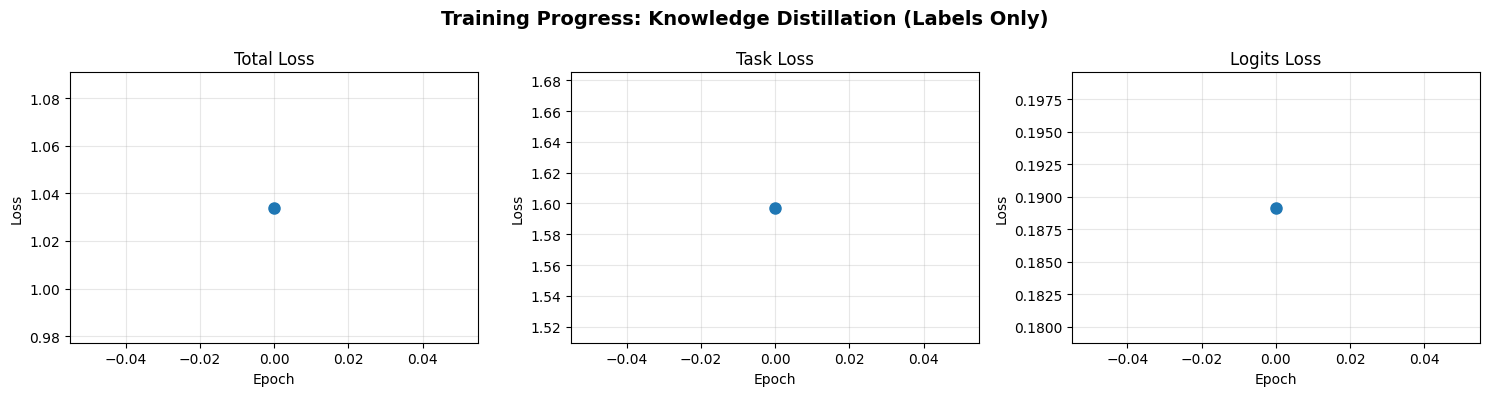

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_keys = [("total", "Total Loss"), ("task", "Task Loss"), ("logits", "Logits Loss")]
for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(stats['loss_history'][key], marker='o', linewidth=2, markersize=8)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('Training Progress: Knowledge Distillation (Labels Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Final lm_eval Benchmarks

In [ ]:
trained_student.eval()
print("Running lm_eval benchmarks...")
print(f"Tasks: {BENCHMARK_TASKS}")
print(f"Rows per task (limit): {BENCHMARK_LIMIT}")
print(f"Batch size: {LMEVAL_BATCH_SIZE}")

student_bench_raw = model_evaluation(
    trained_student,
    tokenizer,
    BENCHMARK_TASKS,
    limit=BENCHMARK_LIMIT,
    device=str(device),
    batch_size=LMEVAL_BATCH_SIZE,
)

def extract_acc(results, task):
    r = results.get(task, {})
    for key in ("accuracy", "acc_norm", "acc"):
        if key in r:
            return float(r[key]) * 100
    return 0.0

student_scores = {task: extract_acc(student_bench_raw, task) for task in BENCHMARK_TASKS}

print("\nBenchmark results (student):")
print(f"{'Task':<20} {'Score':>10}")
print('-' * 32)
for task in BENCHMARK_TASKS:
    print(f"{task:<20} {student_scores[task]:>9.1f}%")

avg_student = sum(student_scores.values()) / len(student_scores)
print('-' * 32)
print(f"{'AVERAGE':<20} {avg_student:>9.1f}%")

In [10]:
student_bench_raw

{'arc_easy': {'accuracy': '0.7350', 'acc_norm': '0.6775'},
 'winogrande': {'accuracy': '0.7025'},
 'hellaswag': {'accuracy': '0.4800', 'acc_norm': '0.6225'},
 'lambada_openai': {'perplexity': '6.21', 'accuracy': '0.6225'},
 'piqa': {'accuracy': '0.7475', 'acc_norm': '0.7725'}}

In [11]:
BASELINE_PROMPT = "Paris is the capital of"
output = get_output(trained_student, tokenizer, BASELINE_PROMPT)
print(f"Pruned model output:\n{output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Pruned model output:
 France and the largest city in Europe. It is located in the north of the country, on the Seine River. The city has a rich history and culture, and is known for its beautiful architecture, museums, and restaurants. There are many things to see and do in Paris, including visiting the Eiffel Tower, the Louvre Museum, and the Notre Dame Cathedral. The city also has a vibrant nightlife scene, with many bars and clubs open late into the night. This section will provide
